# ORBIS Dataset — Exploratory Data Analysis

Dataset: `data/2008-2024_longitudinal_orbis.csv`  
This file merges the longitudinal executive compensation panel (2008–2024) with ORBIS financial data.

**Key questions answered here:**
- How many public companies are covered and which are they?
- What financial variables does ORBIS add?
- How complete is the ORBIS coverage?
- What do the companies look like financially (size, profitability, leverage, R&D)?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

df = pd.read_csv("data/2008-2024_longitudinal_orbis.csv", sep="|", low_memory=False)
print(f"Rows: {len(df):,}  |  Columns: {df.shape[1]}")

ORBIS_COLS = ["CASH","TOAS","SHFD","LTDB","EMPL","TURN","COST","GROS","OPPL",
              "PLBT","TAXA","PL","STAF","DEPR","INTE","RD","CF","EBTA",
              "ROE","ROCE","ROA","PRMA","GRMA","CURR","SOLR","GEAR"]


Rows: 7,505  |  Columns: 189


## 1. Dataset Overview

In [2]:
print("=== STRUCTURE ===")
print(f"Unit of observation: executive x year  ({df['company_person_id'].nunique():,} unique exec-company pairs)")
print(f"Unique companies (ISIN): {df['isin'].nunique()}")
print(f"Unique executives:       {df['exec_id'].nunique():,}")
print(f"Year range:              {df['year'].min()} -- {df['year'].max()}")
print()
print("=== INDEX LISTING (most recent per company) ===")
idx = df.sort_values("year").groupby("isin")["index_listing"].last()
print(idx.value_counts(dropna=False).to_string())
print()
print("=== SOURCE PERIOD ===")
print(df["period"].value_counts(dropna=False).to_string())


=== STRUCTURE ===
Unit of observation: executive x year  (1,519 unique exec-company pairs)
Unique companies (ISIN): 157
Unique executives:       1,447
Year range:              2006 -- 2024

=== INDEX LISTING (most recent per company) ===
index_listing
MDAX            111
DAX              28
DAX and MDAX     15
NaN               3

=== SOURCE PERIOD ===
period
2008-2020    6270
2022-2024    1235


## 2. Which Companies Are in the Dataset?

In [3]:
# One row per company: latest year with ORBIS data
comp = (
    df[df["bvdid"].notna()]
    .sort_values("year")
    .groupby("isin")
    .last()
    .reset_index()
)

display = comp.sort_values("TURN", ascending=False)[
    ["company_name","year","index_listing","TURN","TOAS","EMPL"]
].copy()
display["TURN"] = (display["TURN"] / 1e9).round(1)
display["TOAS"] = (display["TOAS"] / 1e9).round(1)
display["EMPL"] = display["EMPL"].apply(lambda x: f"{int(x):,}" if pd.notna(x) else "N/A")
display.columns = ["Company","Last Year","Index","Revenue (Bn EUR)","Total Assets (Bn EUR)","Employees"]

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 45)
print(f"Companies with ORBIS data: {len(comp)}")
print()
display.reset_index(drop=True)


Companies with ORBIS data: 128



,Company,Last Year,Index,Revenue (Bn EUR),Total Assets (Bn EUR),Employees
0,Volkswagen AG,2024,DAX,337.3,657.5,"614,082"
1,Daimler AG,2024,DAX,151.3,275.3,"175,264"
2,BMW AG,2024,DAX,147.9,278.1,"157,110"
3,Deutsche Telekom AG,2024,DAX,120.3,316.8,"198,194"
4,Deutsche Post AG,2024,DAX,87.5,72.6,"592,407"
5,Siemens AG,2024,DAX,85.0,165.5,"324,000"
6,E.ON SE,2024,DAX,83.2,115.7,"76,566"
7,BASF SE,2024,DAX,67.8,83.5,"111,822"
8,Daimler Truck Holding AG,2024,DAX and MDAX,56.2,76.7,"102,895"
9,Bayer AG,2024,DAX,48.4,115.2,"92,815"


## 3. Panel Coverage Over Time

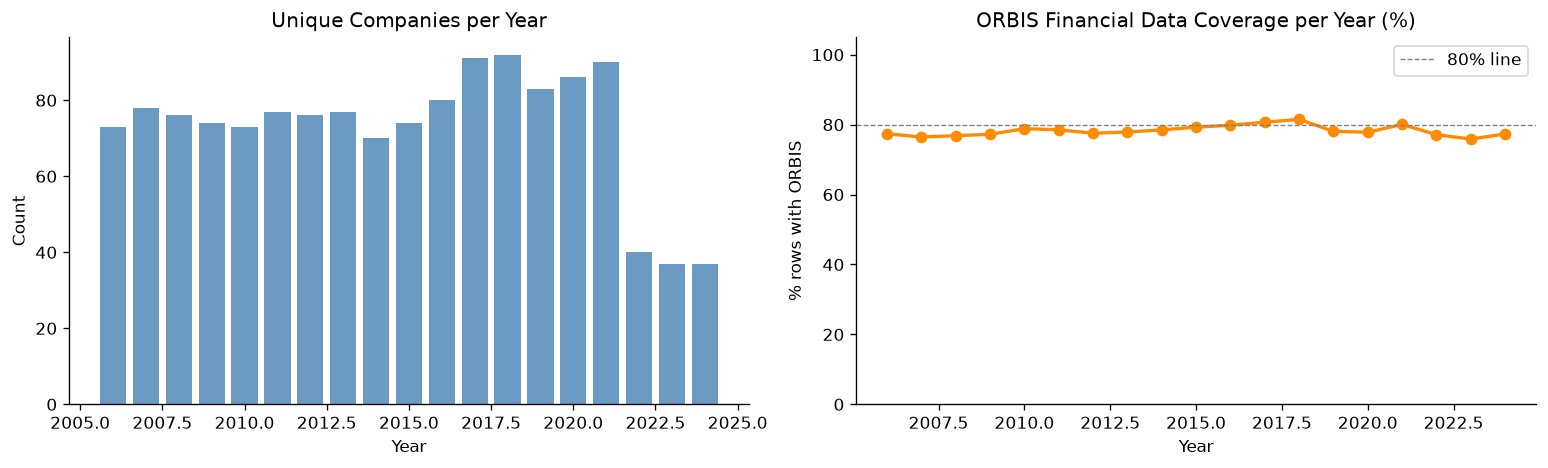

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

companies_per_year = df.groupby("year")["isin"].nunique()
axes[0].bar(companies_per_year.index, companies_per_year.values, color="steelblue", alpha=0.8)
axes[0].set_title("Unique Companies per Year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Count")

orbis_cov = df.groupby("year").apply(lambda x: x["bvdid"].notna().mean() * 100)
axes[1].plot(orbis_cov.index, orbis_cov.values, marker="o", color="darkorange", linewidth=2)
axes[1].axhline(80, color="gray", linestyle="--", linewidth=0.8, label="80% line")
axes[1].set_title("ORBIS Financial Data Coverage per Year (%)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("% rows with ORBIS")
axes[1].set_ylim(0, 105)
axes[1].legend()

plt.tight_layout()
plt.show()


## 4. ORBIS Financial Variables

| Variable | Description |
|---|---|
| CASH | Cash & equivalents |
| TOAS | Total assets |
| SHFD | Shareholders' funds (book equity) |
| LTDB | Long-term debt |
| EMPL | Number of employees |
| TURN | Turnover / Revenue |
| COST | Cost of goods sold |
| GROS | Gross profit |
| OPPL | Operating profit/loss |
| PLBT | Profit/loss before tax |
| TAXA | Taxation |
| PL | Profit/loss after tax |
| STAF | Staff costs |
| DEPR | Depreciation |
| INTE | Interest paid |
| RD | R&D expenditure |
| CF | Cash flow |
| EBTA | EBITDA |
| ROE | Return on equity (%) |
| ROCE | Return on capital employed (%) |
| ROA | Return on assets (%) |
| PRMA | Profit margin (%) |
| GRMA | Gross margin (%) |
| CURR | Current ratio |
| SOLR | Solvency ratio (%) |
| GEAR | Gearing ratio (%) |

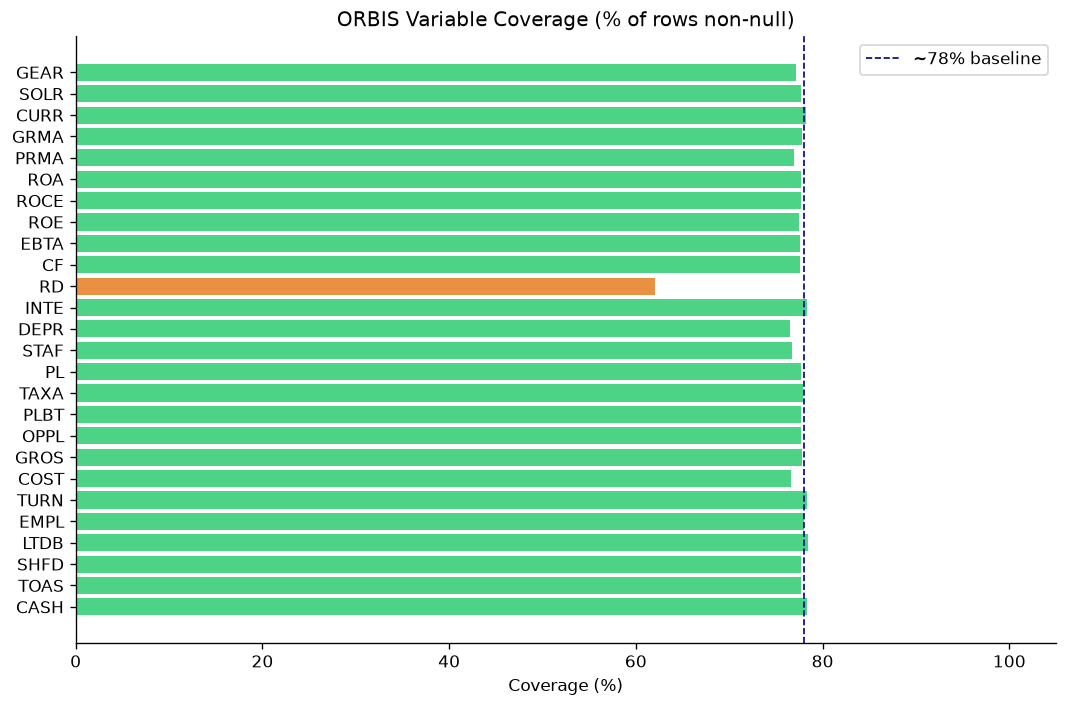

Variable  Non-null  Coverage (%)
    CASH      5873          78.3
    TOAS      5834          77.7
    SHFD      5834          77.7
    LTDB      5882          78.4
    EMPL      5851          78.0
    TURN      5878          78.3
    COST      5747          76.6
    GROS      5836          77.8
    OPPL      5834          77.7
    PLBT      5834          77.7
    TAXA      5843          77.9
      PL      5834          77.7
    STAF      5758          76.7
    DEPR      5741          76.5
    INTE      5878          78.3
      RD      4650          62.0
      CF      5825          77.6
    EBTA      5825          77.6
     ROE      5817          77.5
    ROCE      5830          77.7
     ROA      5828          77.7
    PRMA      5772          76.9
    GRMA      5836          77.8
    CURR      5871          78.2
    SOLR      5834          77.7
    GEAR      5793          77.2

Note: ~22% missing = no ORBIS match (mostly 2022-2024 rows or unmatched ISINs)
RD (R&D) lower at ~62% -- man

In [5]:
coverage = pd.DataFrame({
    "Variable": ORBIS_COLS,
    "Non-null": [df[c].notna().sum() for c in ORBIS_COLS],
    "Coverage (%)": [round(100 * df[c].notna().mean(), 1) for c in ORBIS_COLS]
})

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#2ecc71" if v >= 75 else "#e67e22" if v >= 50 else "#e74c3c"
          for v in coverage["Coverage (%)"]]
ax.barh(coverage["Variable"], coverage["Coverage (%)"], color=colors, alpha=0.85)
ax.axvline(78, color="navy", linestyle="--", linewidth=1, label="~78% baseline")
ax.set_xlabel("Coverage (%)")
ax.set_title("ORBIS Variable Coverage (% of rows non-null)")
ax.set_xlim(0, 105)
ax.legend()
plt.tight_layout()
plt.show()

print(coverage.to_string(index=False))
print()
print("Note: ~22% missing = no ORBIS match (mostly 2022-2024 rows or unmatched ISINs)")
print("RD (R&D) lower at ~62% -- many companies do not disclose this separately.")


## 5. Company Size Distribution

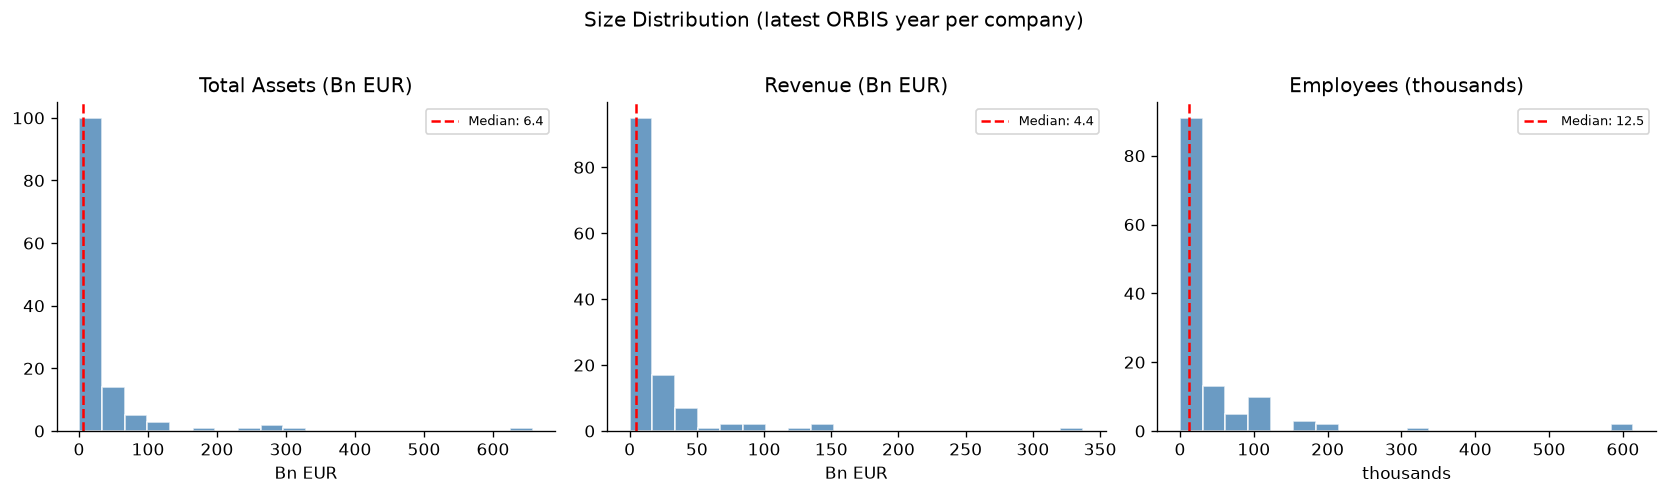

Summary (latest year per company):
       Total Assets (Bn EUR)  Revenue (Bn EUR)  Employees (k)
count                  128.0             128.0          127.0
mean                    31.2              16.9           41.5
std                     77.0              38.6           87.2
min                      0.5               0.0            0.0
25%                      2.5               1.6            4.0
50%                      6.4               4.4           12.5
75%                     21.9              16.9           41.2
max                    657.5             337.3          614.1


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, label, divisor, unit in [
    (axes[0], "TOAS", "Total Assets", 1e9, "Bn EUR"),
    (axes[1], "TURN", "Revenue",       1e9, "Bn EUR"),
    (axes[2], "EMPL", "Employees",    1000, "thousands")
]:
    data = comp[col].dropna() / divisor
    ax.hist(data, bins=20, color="steelblue", alpha=0.8, edgecolor="white")
    ax.axvline(data.median(), color="red", linestyle="--", linewidth=1.5,
               label=f"Median: {data.median():.1f}")
    ax.set_title(f"{label} ({unit})")
    ax.set_xlabel(unit)
    ax.legend(fontsize=8)

plt.suptitle("Size Distribution (latest ORBIS year per company)", y=1.02)
plt.tight_layout()
plt.show()

print("Summary (latest year per company):")
sz = comp[["TOAS","TURN","EMPL"]].copy()
sz["TOAS"] /= 1e9; sz["TURN"] /= 1e9; sz["EMPL"] /= 1000
sz.columns = ["Total Assets (Bn EUR)", "Revenue (Bn EUR)", "Employees (k)"]
print(sz.describe().round(1).to_string())


## 6. Profitability — ROE, ROA, Profit Margin

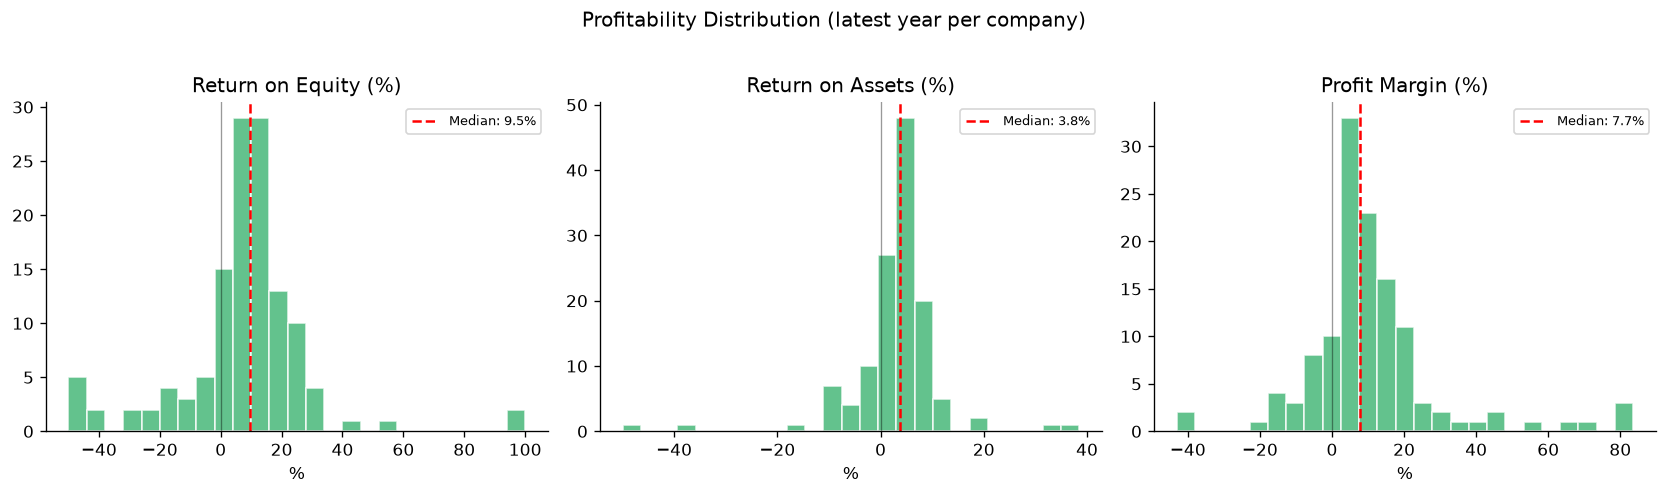

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, label in [
    (axes[0], "ROE",  "Return on Equity (%)"),
    (axes[1], "ROA",  "Return on Assets (%)"),
    (axes[2], "PRMA", "Profit Margin (%)")
]:
    data = comp[col].dropna().clip(-50, 100)
    ax.hist(data, bins=25, color="mediumseagreen", alpha=0.8, edgecolor="white")
    ax.axvline(data.median(), color="red", linestyle="--", linewidth=1.5,
               label=f"Median: {data.median():.1f}%")
    ax.axvline(0, color="black", linewidth=0.8, alpha=0.4)
    ax.set_title(label)
    ax.set_xlabel("%")
    ax.legend(fontsize=8)

plt.suptitle("Profitability Distribution (latest year per company)", y=1.02)
plt.tight_layout()
plt.show()


## 7. Financial Trends Over Time

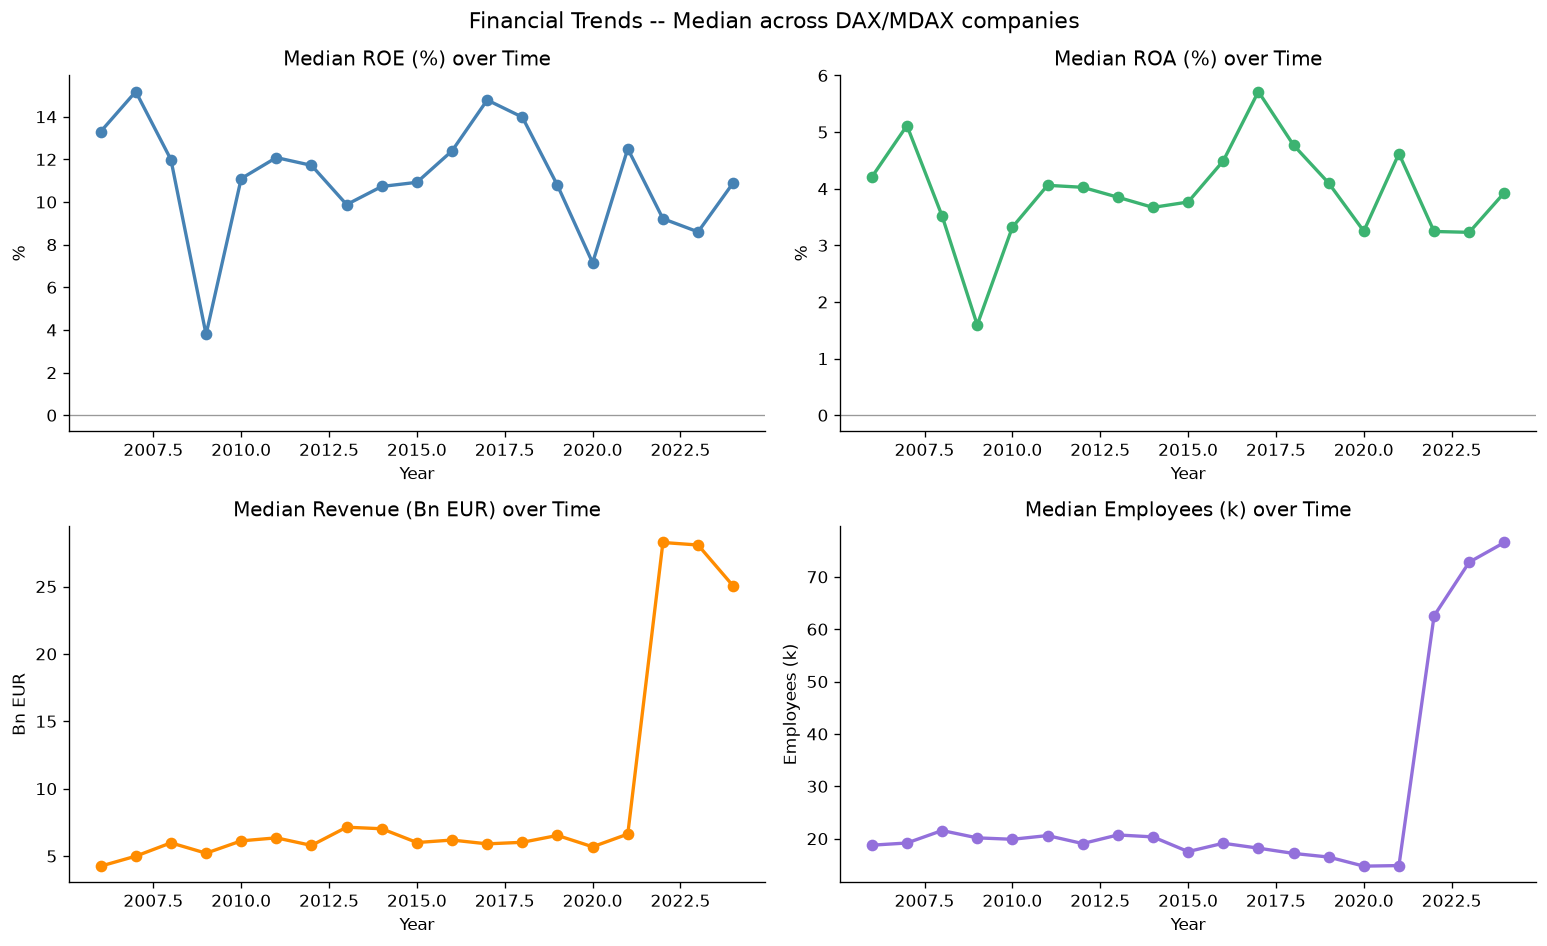

In [8]:
# Deduplicate to one row per company-year before aggregating
cy = df[df["bvdid"].notna()].drop_duplicates(subset=["isin","year"])
yearly = cy.groupby("year")[["ROE","ROA","PRMA","TURN","EMPL"]].median()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0,0].plot(yearly.index, yearly["ROE"], marker="o", color="steelblue", linewidth=2)
axes[0,0].axhline(0, color="black", linewidth=0.8, alpha=0.4)
axes[0,0].set_title("Median ROE (%) over Time")
axes[0,0].set_ylabel("%")

axes[0,1].plot(yearly.index, yearly["ROA"], marker="o", color="mediumseagreen", linewidth=2)
axes[0,1].axhline(0, color="black", linewidth=0.8, alpha=0.4)
axes[0,1].set_title("Median ROA (%) over Time")
axes[0,1].set_ylabel("%")

axes[1,0].plot(yearly.index, yearly["TURN"]/1e9, marker="o", color="darkorange", linewidth=2)
axes[1,0].set_title("Median Revenue (Bn EUR) over Time")
axes[1,0].set_ylabel("Bn EUR")

axes[1,1].plot(yearly.index, yearly["EMPL"]/1000, marker="o", color="mediumpurple", linewidth=2)
axes[1,1].set_title("Median Employees (k) over Time")
axes[1,1].set_ylabel("Employees (k)")

for ax in axes.flat:
    ax.set_xlabel("Year")

plt.suptitle("Financial Trends -- Median across DAX/MDAX companies", fontsize=13)
plt.tight_layout()
plt.show()


## 8. Capital Structure — Leverage & Solvency

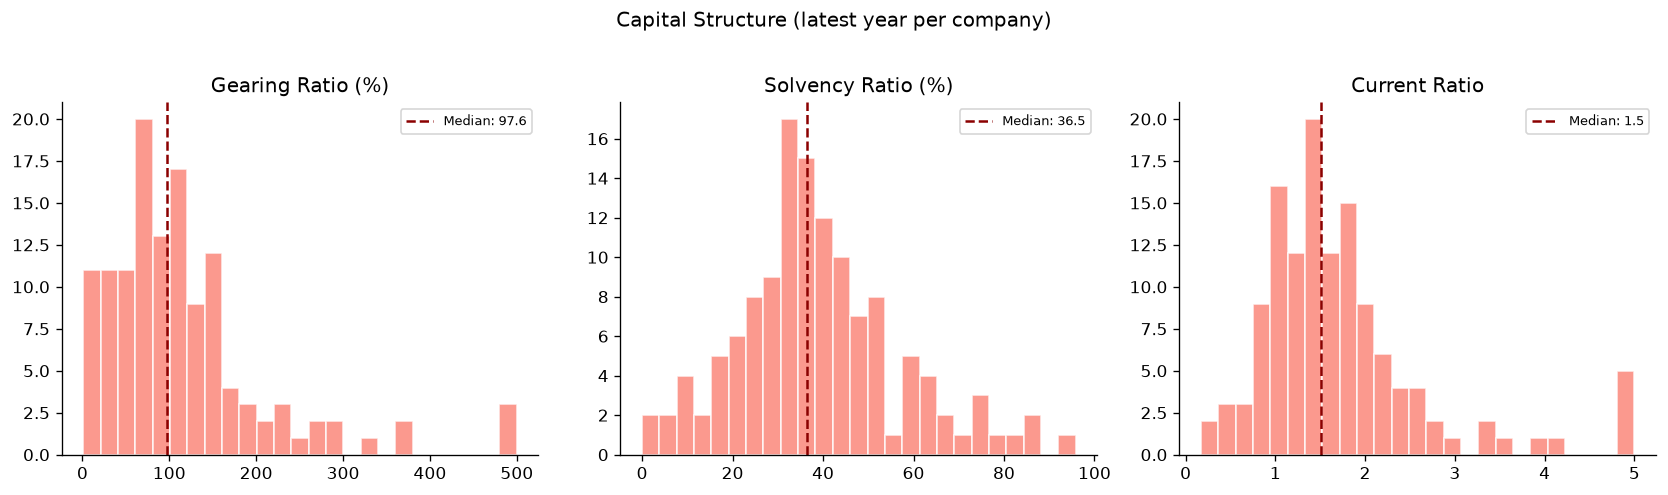

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, label, clip_max in [
    (axes[0], "GEAR", "Gearing Ratio (%)", 500),
    (axes[1], "SOLR", "Solvency Ratio (%)", 100),
    (axes[2], "CURR", "Current Ratio", 5)
]:
    data = comp[col].dropna().clip(0, clip_max)
    ax.hist(data, bins=25, color="salmon", alpha=0.8, edgecolor="white")
    ax.axvline(data.median(), color="darkred", linestyle="--", linewidth=1.5,
               label=f"Median: {data.median():.1f}")
    ax.set_title(label)
    ax.legend(fontsize=8)

plt.suptitle("Capital Structure (latest year per company)", y=1.02)
plt.tight_layout()
plt.show()


## 9. Top & Bottom Companies

In [10]:
print("=== TOP 15 BY REVENUE (Bn EUR) ===")
top_rev = comp.sort_values("TURN", ascending=False)[
    ["company_name","year","index_listing","TURN","EMPL","ROA"]
].head(15).copy()
top_rev["TURN"] = (top_rev["TURN"]/1e9).round(1)
top_rev["EMPL"] = top_rev["EMPL"].apply(lambda x: f"{int(x):,}" if pd.notna(x) else "N/A")
top_rev["ROA"] = top_rev["ROA"].round(1)
top_rev.columns = ["Company","Last Year","Index","Revenue (Bn EUR)","Employees","ROA (%)"]
print(top_rev.to_string(index=False))

print()
print("=== TOP 10 BY ROA ===")
top_roa = comp.sort_values("ROA", ascending=False)[
    ["company_name","year","TURN","ROA","PRMA"]
].head(10).copy()
top_roa["TURN"] = (top_roa["TURN"]/1e9).round(1)
top_roa[["ROA","PRMA"]] = top_roa[["ROA","PRMA"]].round(1)
top_roa.columns = ["Company","Last Year","Revenue (Bn EUR)","ROA (%)","Profit Margin (%)"]
print(top_roa.to_string(index=False))

print()
print("=== BOTTOM 10 BY ROA ===")
bot_roa = comp.sort_values("ROA")[
    ["company_name","year","TURN","ROA","PRMA"]
].head(10).copy()
bot_roa["TURN"] = (bot_roa["TURN"]/1e9).round(1)
bot_roa[["ROA","PRMA"]] = bot_roa[["ROA","PRMA"]].round(1)
bot_roa.columns = ["Company","Last Year","Revenue (Bn EUR)","ROA (%)","Profit Margin (%)"]
print(bot_roa.to_string(index=False))


=== TOP 15 BY REVENUE (Bn EUR) ===
                 Company  Last Year        Index  Revenue (Bn EUR) Employees  ROA (%)
           Volkswagen AG       2024          DAX             337.3   614,082      1.5
              Daimler AG       2024          DAX             151.3   175,264      3.8
                  BMW AG       2024          DAX             147.9   157,110      2.7
     Deutsche Telekom AG       2024          DAX             120.3   198,194      3.7
        Deutsche Post AG       2024          DAX              87.5   592,407      4.8
              Siemens AG       2024          DAX              85.0   324,000      5.6
                 E.ON SE       2024          DAX              83.2    76,566      4.1
                 BASF SE       2024          DAX              67.8   111,822      1.6
Daimler Truck Holding AG       2024 DAX and MDAX              56.2   102,895      3.9
                Bayer AG       2024          DAX              48.4    92,815     -2.3
          Continent

## 10. R&D Spending

Companies with positive R&D data: 75 / 128


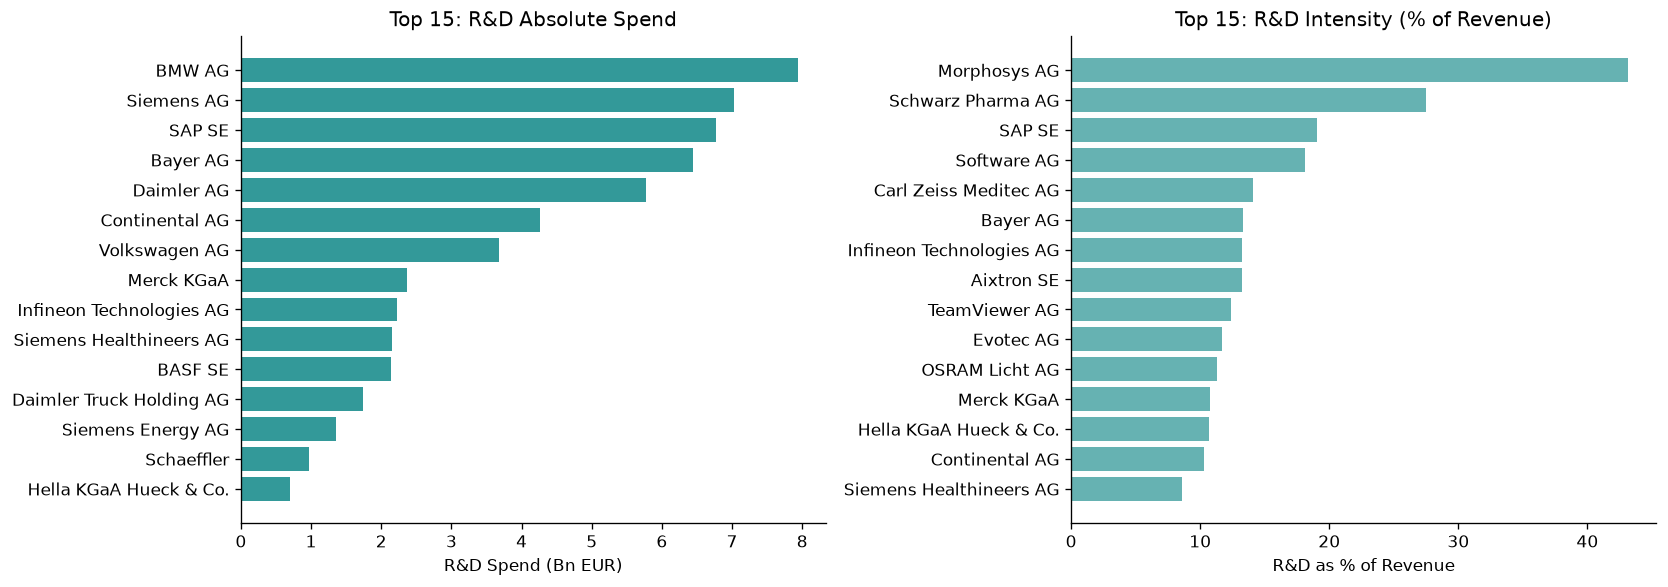

In [11]:
rd_comp = comp[comp["RD"].notna() & (comp["RD"] > 0)].copy()
rd_comp["RD_pct_revenue"] = 100 * rd_comp["RD"] / rd_comp["TURN"]
rd_comp = rd_comp.sort_values("RD", ascending=False)

print(f"Companies with positive R&D data: {len(rd_comp)} / {len(comp)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top15 = rd_comp.head(15)
axes[0].barh(top15["company_name"], top15["RD"]/1e9, color="teal", alpha=0.8)
axes[0].set_xlabel("R&D Spend (Bn EUR)")
axes[0].set_title("Top 15: R&D Absolute Spend")
axes[0].invert_yaxis()

top15_pct = rd_comp.sort_values("RD_pct_revenue", ascending=False).head(15)
axes[1].barh(top15_pct["company_name"], top15_pct["RD_pct_revenue"], color="teal", alpha=0.6)
axes[1].set_xlabel("R&D as % of Revenue")
axes[1].set_title("Top 15: R&D Intensity (% of Revenue)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


## 11. ORBIS Match Quality & Reporting Units

In [12]:
matched = df["bvdid"].notna()
print(f"Rows WITH ORBIS data:    {matched.sum():,} ({100*matched.mean():.1f}%)")
print(f"Rows WITHOUT ORBIS data: {(~matched).sum():,} ({100*(~matched).mean():.1f}%)")
print()
print("=== CONSOLIDATION CODE ===")
print("C2 = fully consolidated, C1 = limited consolidated")
print(df["CONSCODE"].value_counts(dropna=False).to_string())
print()
print("=== REPORTING UNITS ===")
print(df["ORIG_UNITS"].value_counts(dropna=False).to_string())
print()
print("WARNING: values are in ORIGINAL units (thousands / millions / billions EUR).")
print("  Always check ORIG_UNITS before computing ratios or comparing companies!")
print()
no_orbis = set(df[~matched]["isin"].unique()) - set(df[matched]["isin"].unique())
print(f"Companies NEVER matched in ORBIS: {len(no_orbis)}")
if no_orbis:
    names = df[df["isin"].isin(no_orbis)][["isin","company_name"]].drop_duplicates()
    print(names.to_string(index=False))


Rows WITH ORBIS data:    5,882 (78.4%)
Rows WITHOUT ORBIS data: 1,623 (21.6%)

=== CONSOLIDATION CODE ===
C2 = fully consolidated, C1 = limited consolidated
CONSCODE
C2     5265
NaN    1623
C1      617

=== REPORTING UNITS ===
ORIG_UNITS
thousands    4384
NaN          1623
millions     1496
billions        2

  Always check ORIG_UNITS before computing ratios or comparing companies!

Companies NEVER matched in ORBIS: 29
         isin                             company_name
 DE0005408116                           Aareal Bank AG
 DE0008404005                               Allianz SE
 LU1673108939                          Aroundtown S.A.
 LU1704650164                                Befesa SA
 DE000CLS1001                               Celesio AG
 DE000CBK1001                           Commerzbank AG
 DE0008019001               Deutsche Pfandbriefbank AG
 DE0005140008                         Deutsche Bank AG
 DE0008001009                     Deutsche Postbank AG
 NL0000235190              

## 12. Key Findings Summary

| Aspect | Finding |
|---|---|
| **Coverage** | 157 unique companies (by ISIN), all German DAX/MDAX listed |
| **Period** | 2006–2024, densest coverage 2008–2021 |
| **ORBIS match** | ~78% of rows have ORBIS financials (matched via BvD ID) |
| **Consolidation** | Mostly C2 (fully consolidated group accounts) |
| **Units** | EUR; but units vary per row — **must normalize before comparing** |
| **Size** | Median revenue ~4.4 Bn EUR, median employees ~12,500 — large-cap universe |
| **Profitability** | Median ROA ~4%, ROE ~9%, profit margin ~8% |
| **R&D** | ~62% have R&D data; automotive (VW, BMW, Daimler) & pharma (Bayer) dominate |
| **Missing** | RD lowest coverage (~62%); all other ORBIS vars ~77–78% |

**Architecture note:** ORBIS financials repeat across all executive rows for the same company-year.  
Always `drop_duplicates(subset=['isin','year'])` before any firm-level aggregation.